Epoch 1/30
20/20 [==============================] - 162s 8s/step - loss: 0.9164 - accuracy: 0.4531 - val_loss: 0.6927 - val_accuracy: 0.5437
Epoch 2/30
20/20 [==============================] - 150s 8s/step - loss: 0.6974 - accuracy: 0.4797 - val_loss: 0.6938 - val_accuracy: 0.4563
Epoch 3/30
20/20 [==============================] - 153s 8s/step - loss: 0.6933 - accuracy: 0.4828 - val_loss: 0.6934 - val_accuracy: 0.4563
Epoch 4/30
20/20 [==============================] - 143s 7s/step - loss: 0.6934 - accuracy: 0.4938 - val_loss: 0.6924 - val_accuracy: 0.5437
Epoch 5/30
20/20 [==============================] - 144s 7s/step - loss: 0.6926 - accuracy: 0.5266 - val_loss: 0.6926 - val_accuracy: 0.5437
Epoch 6/30
20/20 [==============================] - 142s 7s/step - loss: 0.6932 - accuracy: 0.5156 - val_loss: 0.6924 - val_accuracy: 0.5437
Epoch 7/30
20/20 [==============================] - 126s 6s/step - loss: 0.6934 - accuracy: 0.5063 - val_loss: 0.6927 - val_accuracy: 0.5437
Epoch 8/30
20

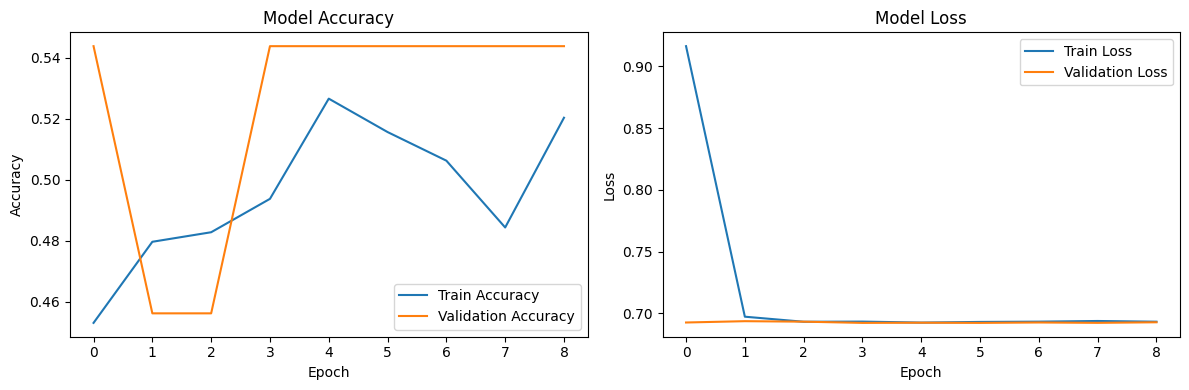

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, LSTM, Dense, TimeDistributed, Dropout, Bidirectional, Input, Layer
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow.keras.backend as K
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv('binary_classification_dataset.csv')

# Sample dataset generation for demonstration (Replace this with actual data loading)
np.random.seed(42)  # For reproducibility
num_samples = 1000  # Number of samples
time_steps = 30  # Number of time steps
height, width = 64, 64  # Image dimensions

# Generating random features and binary targets
X = np.random.rand(num_samples, time_steps, height, width, 1)  # Random features
y = np.random.randint(0, 2, size=(num_samples,))  # Binary targets (0 or 1)

# Create DataFrame (for the sake of example)
df = pd.DataFrame(X.reshape(num_samples, -1))  # Flatten the input for DataFrame
df['target'] = y  # Append binary target to DataFrame

# Preprocessing function
def preprocess_data(df):
    X = df.iloc[:, :-1].values  # Features (all columns except the last)
    y = df.iloc[:, -1].values    # Target (last column)
    X = X.reshape(-1, time_steps, height, width, 1)  # Reshape for CNN (time steps, height, width, channels)
    
    # Scale features
    scaler = MinMaxScaler()
    X = scaler.fit_transform(X.reshape(-1, height * width)).reshape(-1, time_steps, height, width, 1)
    
    return X, y

# Prepare your data
X, y = preprocess_data(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Attention Mechanism
class Attention(Layer):
    def _init_(self, **kwargs):
        super(Attention, self)._init_(**kwargs)

    def call(self, inputs):
        # inputs shape: (batch_size, time_steps, features)
        # Compute attention weights
        attention_weights = K.softmax(K.batch_dot(inputs, K.permute_dimensions(inputs, (0, 2, 1))), axis=-1)
        context_vector = K.batch_dot(attention_weights, inputs)  # (batch_size, time_steps, features)
        return context_vector

# Build the Hybrid CNN-Bi-Directional LSTM model with Attention
def build_model(input_shape):
    model = Sequential()
    
    # Input layer
    model.add(Input(shape=input_shape))  # Use Input layer for proper shape definition
    
    # CNN layers
    model.add(TimeDistributed(Conv2D(32, (3, 3), activation='relu')))
    model.add(TimeDistributed(MaxPooling2D(pool_size=(2, 2))))
    model.add(TimeDistributed(Conv2D(64, (3, 3), activation='relu')))
    model.add(TimeDistributed(MaxPooling2D(pool_size=(2, 2))))
    model.add(TimeDistributed(Flatten()))

    # Attention layer
    model.add(Attention())

    # LSTM layers
    model.add(Bidirectional(LSTM(100, return_sequences=False)))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))  # Binary classification output
    
    return model

# Model input shape
input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3], X_train.shape[4])  # (time_steps, height, width, channels)
model = build_model(input_shape)

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Set up early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, 
                    epochs=30, 
                    batch_size=32, 
                    validation_split=0.2, 
                    callbacks=[early_stopping])

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy * 100:.2f}%')

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()